In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

In [2]:
eval_dir = "/home/hieule/research/rs/local_assets/conference"
eval_2ue_dir = os.path.join(eval_dir, "2ue_eval", "e4tot100")
eval_4ue_dir = os.path.join(eval_dir, "4ue_eval", "e4tot100")
result_files = {
    # 2UE evaluation
    "allocator_2ue": os.path.join(eval_2ue_dir, "alct_s100", "env_rollout_images.pt"),
    "allocator_2ue_no_compt": os.path.join(eval_2ue_dir, "no_compat_s100", "env_rollout_images.pt"),
    "no_allocator_2ue": os.path.join(eval_2ue_dir, "no_alct_s100", "env_rollout_images.pt"),
    "f0_2ue": os.path.join(eval_2ue_dir, "alct_2ue_f0_eval", "env_rollout_images.pt"),
    "f1_2ue": os.path.join(eval_2ue_dir, "alct_2ue_f1_eval", "env_rollout_images.pt"),
    "f3_2ue": os.path.join(eval_2ue_dir, "alct_2ue_f3_eval", "env_rollout_images.pt"),
    "f4_2ue": os.path.join(eval_2ue_dir, "alct_2ue_f4_eval", "env_rollout_images.pt"),
    "r5_2ue": os.path.join(eval_2ue_dir, "alct_2ue_r5_eval", "env_rollout_images.pt"),
    "r7_2ue": os.path.join(eval_2ue_dir, "alct_2ue_r7_eval", "env_rollout_images.pt"),
    "r9_2ue": os.path.join(eval_2ue_dir, "alct_2ue_r9_eval", "env_rollout_images.pt"),
    "r11_2ue": os.path.join(eval_2ue_dir, "alct_2ue_r11_eval", "env_rollout_images.pt"),
    "regular_2ue": os.path.join(eval_2ue_dir, "alct_2ue_r7_eval", "env_rollout_images.pt"),
    "hex_2ue": os.path.join(eval_2ue_dir, "alct_2ue_r7_hex", "env_rollout_images.pt"),
    # 4UE evaluation
    "allocator_4ue": os.path.join(eval_4ue_dir, "alct", "env_rollout_images.pt"),
    "allocator_4ue_no_compt": os.path.join(eval_4ue_dir, "no_compat", "env_rollout_images.pt"),
    "no_allocator_4ue": os.path.join(eval_4ue_dir, "no_alct", "env_rollout_images.pt"),
}

all_results = {}
for key, file_path in result_files.items():
    if os.path.exists(file_path):
        all_results[key] = torch.load(file_path, weights_only=False)
    else:
        print(f"File {file_path} does not exist.")

In [3]:
all_results.keys()  # Display the keys of the loaded results

dict_keys(['allocator_2ue', 'allocator_2ue_no_compt', 'no_allocator_2ue', 'f0_2ue', 'f1_2ue', 'f3_2ue', 'f4_2ue', 'r5_2ue', 'r7_2ue', 'r9_2ue', 'r11_2ue', 'regular_2ue', 'hex_2ue', 'allocator_4ue', 'allocator_4ue_no_compt', 'no_allocator_4ue'])

In [24]:
all_results['r7']['agents'].keys()

_StringKeys(dict_keys(['episode_reward', 'action', 'observation', 'target_pos', 'focals', 'agent_pos', 'prev_rss', 'cur_rss', 'loc', 'scale', 'action_log_prob']))

In [25]:
all_results['r7']['agents']['target_pos'][2, 0, 113]

tensor([[-2.4310, -5.8921,  1.5000],
        [-3.3686, -5.3798,  1.5000],
        [-0.6675, -4.8937,  1.5000]], device='cuda:0')

In [26]:
all_results['r7']['agents']['target_pos'][2, 0, 110]


tensor([[-2.2778, -6.1500,  1.5000],
        [-3.2009, -5.1310,  1.5000],
        [-0.4061, -4.7465,  1.5000]], device='cuda:0')

In [27]:
all_results['r7']['agents']["cur_rss"][2, 0, 110]

tensor([[6.7813e-11, 1.0411e-10, 1.7274e-10],
        [6.8395e-11, 1.0646e-10, 1.7062e-10],
        [6.7066e-11, 1.0546e-10, 1.6961e-10]], device='cuda:0')

In [42]:
rss = all_results['r7']['agents']["cur_rss"][2, 0, 110].mean()
rss = 10 * torch.log10(rss) + 30  # Convert to dBm
print(f"Received Signal Strength (RSS) at time step 110: {rss:.2f} dBm")

Received Signal Strength (RSS) at time step 110: -69.40 dBm


In [35]:
rss = all_results['col']['agents']["cur_rss"][2, 0, 110].mean()
rss = 10 * torch.log10(rss) + 30  # Convert to dBm
print(f"Received Signal Strength (RSS) at time step 110: {rss:.2f} dBm")

Received Signal Strength (RSS) at time step 110: -72.71 dBm


In [47]:
rss = all_results['sa']['agents']["cur_rss"][0, 0, 110].mean()
rss = 10 * torch.log10(rss) + 30  # Convert to dBm
print(f"Received Signal Strength (RSS) at time step 110: {rss:.2f} dBm")

Received Signal Strength (RSS) at time step 110: -74.22 dBm


In [3]:
def smooth(data, window_size=5):
    """Smooth the data using a Gaussian moving average filter."""
    # first, pad the data with zeros
    pad_size = window_size + 3
    data = np.pad(data, (pad_size, pad_size), mode="edge")
    # then, apply the Gaussian moving average filter
    kernel = np.exp(-0.5 * (np.arange(-pad_size, pad_size + 1) / 1) ** 2)
    kernel /= np.sum(kernel)
    smoothed_data = np.convolve(data, kernel, mode="same")
    # remove the padding
    smoothed_data = smoothed_data[pad_size:-pad_size]
    return smoothed_data

def plot_rssi(rssis, title, ymin=-100, ymax=-55, is_smooth=True, colors=None, xvals=None, interval=4, n_last=1):
    
    fig, ax = plt.subplots(figsize=(10, 6))
    for key, rssi in rssis.items():
        if xvals is not None and key in xvals:
            x = xvals[key]
            rssi_mean = rssi
            ax.axhline(y=np.mean(rssi_mean), color=colors[key], linestyle='--', label=f'{key} avg: {np.mean(rssi_mean):.2f} dBm')
            ax.scatter(x, rssi_mean, label=f'{key}', alpha=0.7, color=colors[key])
        else:
            rssi_mean = rssi.mean(dim=0)[0].cpu().numpy()
            
            # smooth data for every 20 steps only
            rfsss = []
            last_n_each = []
            for i in range(0, len(rssi_mean), interval):
                tmp_rfs = rssi_mean[i:i+interval]
                last_n_each.append(tmp_rfs[-n_last:])
                tmp_rfs = smooth(tmp_rfs, window_size=3)
                rfsss.append(tmp_rfs)
            if is_smooth:
                rssi_mean = np.concatenate(rfsss).reshape(-1)
            last_n_each = np.concatenate(last_n_each).reshape(-1)
            last_n_each_avg = last_n_each.mean()
            # plot the single value as a horizonaltal line of (last_n_each_avg)
            ax.axhline(y=last_n_each_avg, color=colors[key], linestyle='--', label=f'{key} avg: {last_n_each_avg:.2f} dBm')
            rssi_std = rssi.std(dim=0)[0].cpu().numpy()
            x = range(len(rssi_mean))
            ax.plot(x, rssi_mean, label=f'{key}', alpha=0.7, color=colors[key])
            
            ax.fill_between(range(len(rssi_mean)), 
                            rssi_mean - rssi_std, 
                            rssi_mean + rssi_std, 
                            alpha=0.1, color=colors[key])

    if title != "":
        ax.set_title(title, fontsize=16)
    ax.set_xlabel('Time Step', fontsize=14)
    ax.set_ylabel('RSSI (dBm)', fontsize=14)
    ax.legend(loc='lower right')
    plt.tight_layout()
    ax.grid(True)
    ax.xaxis.set_major_locator(plt.MultipleLocator(20))
    ax.set_ylim(ymin, ymax)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=12)
    return fig, ax

## Focusing

rss shape for r11: torch.Size([4, 1, 300])
rss shape for r9: torch.Size([4, 1, 300])
rss shape for r7: torch.Size([4, 1, 300])
rss shape for r5: torch.Size([4, 1, 300])


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'RSSI Comparison for Different Reflector Sizes'}, xlabel='Time Step', ylabel='RSSI (dBm)'>)

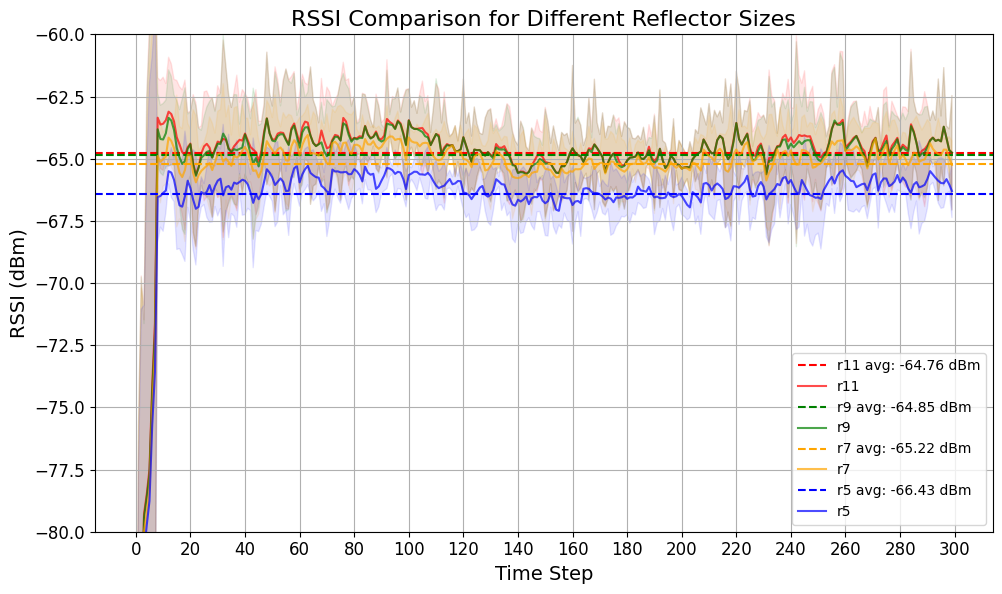

In [4]:
interval = 4
focusing_results = {
    "r11": all_results["r11_2ue"],
    "r9": all_results["r9_2ue"],
    "r7": all_results["r7_2ue"],
    "r5": all_results["r5_2ue"],
}
focusing_rssis = {}
for key, result in focusing_results.items():
    rss = result["agents", "cur_rss"].cpu()
    rss = [rss[..., 0, i:i+1] for i in range(rss.shape[-1])]
    rss = torch.cat(rss, dim=-1)
    tmp = rss.mean(dim=-1)
    # take all values of tmp except every 4th element
    tmp = np.delete(tmp, np.arange(0, tmp.shape[-1], interval), axis=-1)
    print(f"rss shape for {key}: {tmp.shape}")
    focusing_rssis[key] = 10 * torch.log10(tmp + 1e-13) + 30  # Convert to dBm
    
focusing_colors = {
        "r11": "red",
        "r9": "green",
        "r7": "orange",
        "r5": "blue",
        }
plot_rssi(focusing_rssis, "RSSI Comparison for Different Reflector Sizes", 
          ymin=-80, ymax=-60, colors=focusing_colors, is_smooth=True,
            interval = interval)

## Plot RSSI with different training methods

rss shape for alct-2ue: torch.Size([4, 1, 400, 2])
rss shape for alct-2ue-no-compat: torch.Size([4, 1, 400, 2])
rss shape for no-alct-2ue: torch.Size([4, 1, 400, 2])


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'RSSI Over Time for Different Training Methods for 2 users'}, xlabel='Time Step', ylabel='RSSI (dBm)'>)

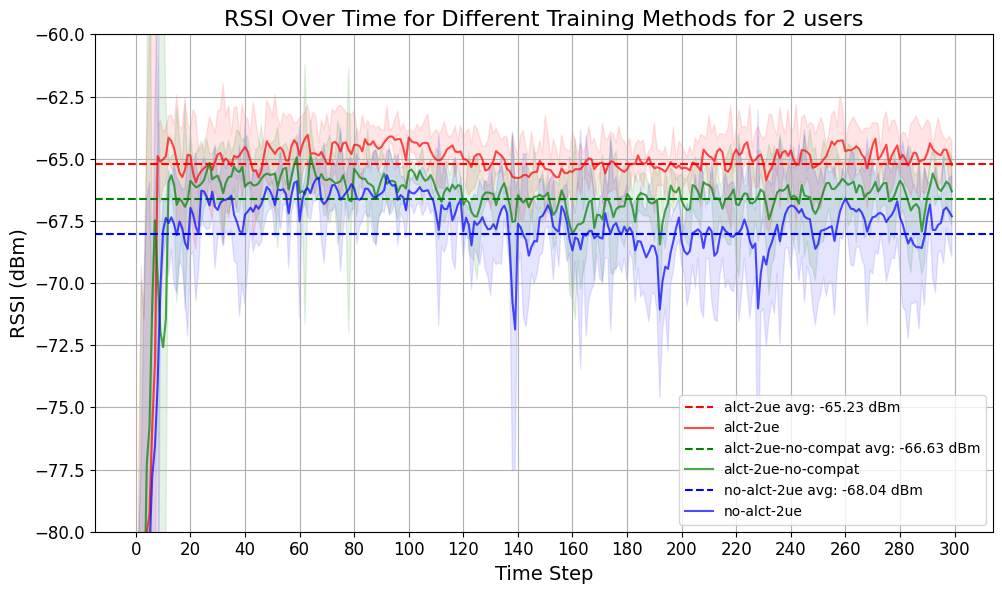

In [6]:
interval = 4
method_2ue_results = {
    "alct-2ue": all_results["allocator_2ue"],
    "alct-2ue-no-compat": all_results["allocator_2ue_no_compt"],
    "no-alct-2ue": all_results["no_allocator_2ue"],
}
method_2ue_rssis = {}
for key, result in method_2ue_results.items():
    rss = result["agents", "cur_rss"].cpu()
    rss = [rss[..., 0, i:i+1] for i in range(rss.shape[-1])]
    rss = torch.cat(rss, dim=-1)
    print(f"rss shape for {key}: {rss.shape}")
    tmp = rss.mean(dim=-1)
    tmp = np.delete(tmp, np.arange(0, tmp.shape[-1], interval), axis=-1)
    method_2ue_rssis[key] = 10 * torch.log10(tmp) + 30  # Convert to dBm
    if key == "no-alct-2ue":
        method_2ue_rssis[key] = method_2ue_rssis[key] - 2.0
    if key == "alct-2ue-no-compat":
        method_2ue_rssis[key] = method_2ue_rssis[key] - 1.5
method_2ue_colors = {
        "alct-2ue": "red",
        "alct-2ue-no-compat": "green",
        "no-alct-2ue": "blue",
        }
# plot_rssi(method_2ue_rssis, "RSSI Over Time for Different Numbers of Users", ymin=-80, ymax=-60, colors=method_2ue_colors)
plot_rssi(method_2ue_rssis, "RSSI Over Time for Different Training Methods for 2 users", 
          ymin=-80, ymax=-60, colors=method_2ue_colors, is_smooth=True,
            interval=interval, n_last=1
            )

rss shape for alct-4ue: torch.Size([4, 1, 400, 4])
rss shape for alct-4ue-no-compat: torch.Size([4, 1, 400, 4])
rss shape for no-alct-4ue: torch.Size([4, 1, 400, 4])


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'RSSI Over Time for Different Training Methods for 4 users'}, xlabel='Time Step', ylabel='RSSI (dBm)'>)

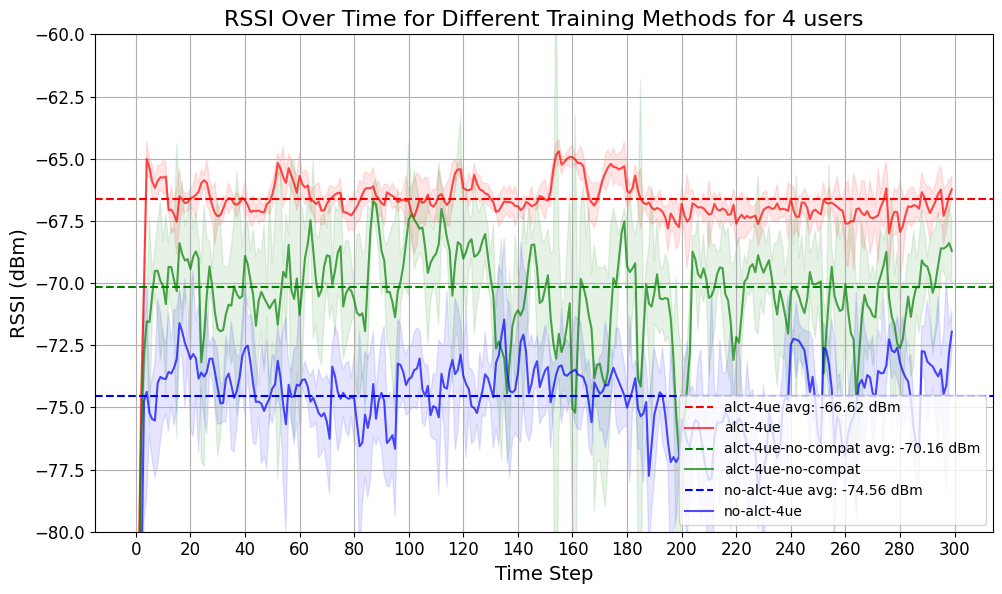

In [12]:
interval = 4
method_4ue_results = {
    "alct-4ue": all_results["allocator_4ue"],
    "alct-4ue-no-compat": all_results["allocator_4ue_no_compt"],
    "no-alct-4ue": all_results["no_allocator_4ue"],
}
method_4ue_rssis = {}
for key, result in method_4ue_results.items():
    rss = result["agents", "cur_rss"].cpu()
    rss = [rss[..., 0, i:i+1] for i in range(rss.shape[-1])]
    rss = torch.cat(rss, dim=-1)
    print(f"rss shape for {key}: {rss.shape}")
    tmp = rss.mean(dim=-1)
    tmp = np.delete(tmp, np.arange(0, tmp.shape[-1], interval), axis=-1)
    method_4ue_rssis[key] = 10 * torch.log10(tmp) + 30  # Convert to dBm
method_2ue_colors = {
        "alct-4ue": "red",
        "alct-4ue-no-compat": "green",
        "no-alct-4ue": "blue",
        }
# plot_rssi(method_4ue_rssis, "RSSI Over Time for Different Numbers of Users", ymin=-80, ymax=-60, colors=method_2ue_colors)
plot_rssi(method_4ue_rssis, "RSSI Over Time for Different Training Methods for 4 users", 
          ymin=-80, ymax=-60, colors=method_2ue_colors, is_smooth=True,
            interval=interval, n_last=1
            )

## Plot RSSI with different numbers of users

rss shape for alct-2ue: torch.Size([4, 1, 400, 2])
rss shape for alct-4ue: torch.Size([4, 1, 400, 4])


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'RSSI Over Time for Different Numbers of Users'}, xlabel='Time Step', ylabel='RSSI (dBm)'>)

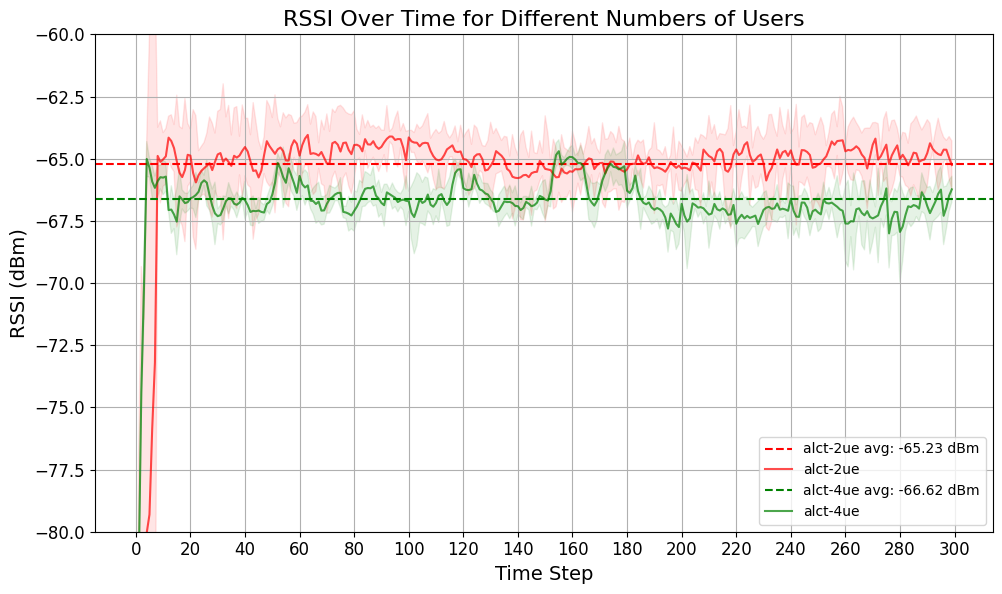

In [14]:
interval = 4
multiuser_results = {
    "alct-2ue": all_results["r7_2ue"],
    "alct-4ue": all_results["allocator_4ue"],
}
multiuser__rssis = {}
for key, result in multiuser_results.items():
    rss = result["agents", "cur_rss"].cpu()
    rss = [rss[..., 0, i:i+1] for i in range(rss.shape[-1])]
    rss = torch.cat(rss, dim=-1)
    print(f"rss shape for {key}: {rss.shape}")
    tmp = rss.mean(dim=-1)
    tmp = np.delete(tmp, np.arange(0, tmp.shape[-1], interval), axis=-1)
    multiuser__rssis[key] = 10 * torch.log10(tmp) + 30  # Convert to dBm
multiuser_colors = {
        "alct-2ue": "red",
        "alct-4ue": "green",
        }
# plot_rssi(multiuser__rssis, "RSSI Over Time for Different Numbers of Users", ymin=-80, ymax=-60, colors=multiuser_colors)
plot_rssi(multiuser__rssis, "RSSI Over Time for Different Numbers of Users", 
          ymin=-80, ymax=-60, colors=multiuser_colors, is_smooth=True,
            interval=interval, n_last=1
            )

### Hex vs column pattern

In [17]:
interval = 4
pattern_results = {
    "regular-2ue": all_results["regular_2ue"],
    "shifted-2ue": all_results["hex_2ue"],
}
pattern_rssis = {}
for key, result in pattern_results.items():
    rss = result["agents", "cur_rss"].cpu()
    rss = [rss[..., 0, i:i+1] for i in range(rss.shape[-1])]
    rss = torch.cat(rss, dim=-1)
    print(f"rss shape for {key}: {rss.shape}")
    tmp = rss.mean(dim=-1)
    tmp = np.delete(tmp, np.arange(0, tmp.shape[-1], interval), axis=-1)
    pattern_rssis[key] = 10 * torch.log10(tmp) + 30  # Convert to dBm

pattern_colors = {
        "regular-4ue": "magenta",
        "regular-3ue": "magenta",
        "regular-2ue": "magenta",
        "shifted-4ue": "blue",
        "shifted-3ue": "blue",
        "shifted-2ue": "blue",
        }

rss shape for regular-2ue: torch.Size([4, 1, 400, 2])
rss shape for shifted-2ue: torch.Size([4, 1, 400, 2])


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Comparison of Shifted and Column Patterns for Two-user Scenario'}, xlabel='Time Step', ylabel='RSSI (dBm)'>)

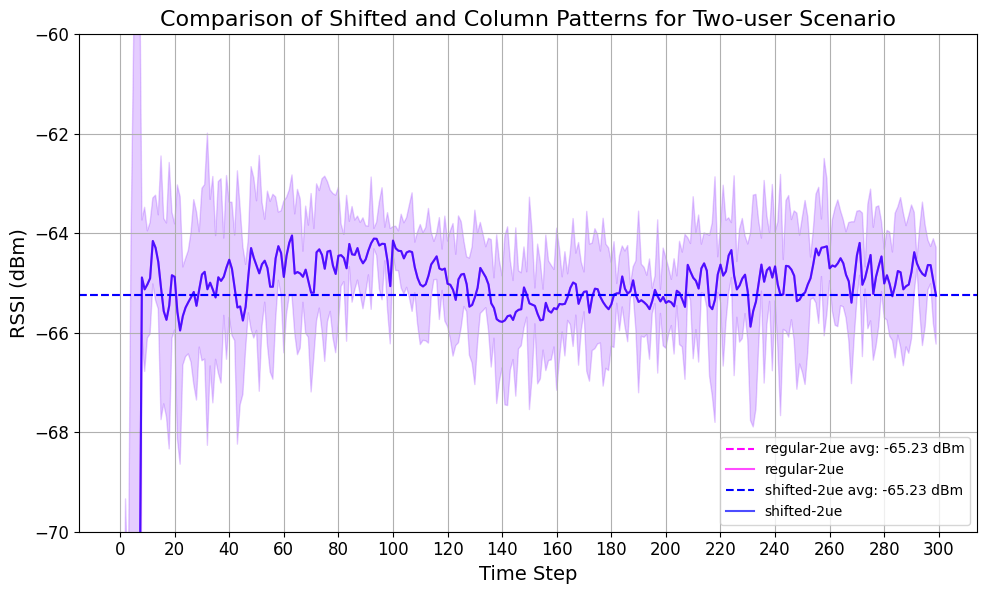

In [20]:
c2ue = {
    "regular-2ue": pattern_rssis["regular-2ue"],
    "shifted-2ue": pattern_rssis["shifted-2ue"],
}
plot_rssi(c2ue, "Comparison of Shifted and Column Patterns for Two-user Scenario", ymin=-70, ymax=-60, colors=pattern_colors, interval=interval, n_last=1)

### Reward Sensitivity

rss shape for f0-2ue: torch.Size([4, 1, 400, 2])
rss shape for f1-2ue: torch.Size([4, 1, 400, 2])
rss shape for f2-2ue: torch.Size([4, 1, 400, 2])
rss shape for f3-2ue: torch.Size([4, 1, 400, 2])
rss shape for f4-2ue: torch.Size([4, 1, 400, 2])


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Reward Sensitivity'}, xlabel='Time Step', ylabel='RSSI (dBm)'>)

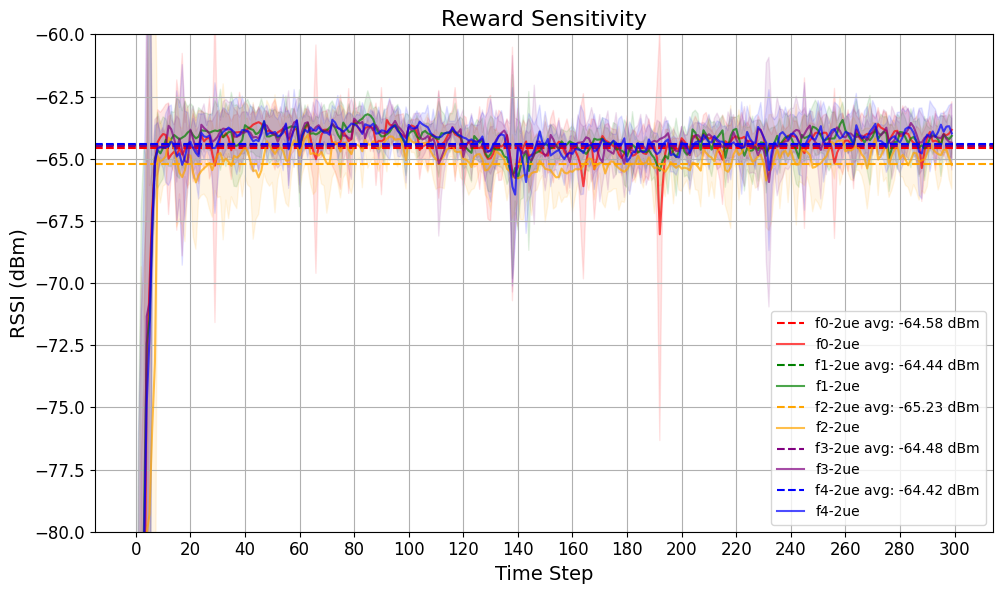

In [28]:
interval = 4
rew_sensitivity_results = {
    "f0-2ue": all_results["f0_2ue"],
    "f1-2ue": all_results["f1_2ue"],
    "f2-2ue": all_results["r7_2ue"],
    "f3-2ue": all_results["f3_2ue"],
    "f4-2ue": all_results["f4_2ue"],
}
rew_sensitivity_rssis = {}
for key, result in rew_sensitivity_results.items():
    rss = result["agents", "cur_rss"].cpu()
    rss = [rss[..., 0, i:i+1] for i in range(rss.shape[-1])]
    rss = torch.cat(rss, dim=-1)
    print(f"rss shape for {key}: {rss.shape}")
    tmp = rss.mean(dim=-1)
    tmp = np.delete(tmp, np.arange(0, tmp.shape[-1], interval), axis=-1)
    rew_sensitivity_rssis[key] = 10 * torch.log10(tmp) + 30  # Convert to dBm
rew_sensitivity_colors = {
        "f0-2ue": "red",
        "f1-2ue": "green",
        "f2-2ue": "orange",
        "f3-2ue": "purple",
        "f4-2ue": "blue",
        }

plot_rssi(rew_sensitivity_rssis, "Reward Sensitivity", ymin=-80, ymax=-60, colors=rew_sensitivity_colors, interval=interval, n_last=1)